In [1]:
from aeon.anomaly_detection.series.distribution_based import COPOD
from utils.evaluation import evaluate_model
from utils.data_loader_hai import load_hai_train
from utils.evaluation_hai import cross_validate_hai
result_path = "../Results/HAI COPOD"

C:\Users\louis\PycharmProjects\Exjobb-Gitrepo\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
static_params = {
    "window_size": 50,
    "stride": 5,
    "n_jobs": 1
}

cross_val_scores = cross_validate_hai(model=COPOD, params=static_params, result_path=result_path)
print(cross_val_scores)

{'fold1_roc_auc': 0.8041117097286051, 'fold1_pr_auc': 0.37303656024119974, 'fold2_roc_auc': 0.6032891444359548, 'fold2_pr_auc': 0.01716409169569103, 'fold3_roc_auc': 0.8008079435538724, 'fold3_pr_auc': 0.36580622252236283, 'fold4_roc_auc': 0.5875321704884761, 'fold4_pr_auc': 0.013419117976479617, 'mean_threshold': np.float64(5169.92246714831)}


In [3]:
X_train, X_test, y_test = load_hai_train()

model = COPOD(window_size=50, stride=5, n_jobs=1)

model.fit(X_train, axis=0)

scores = model.predict(X_test, axis=0)

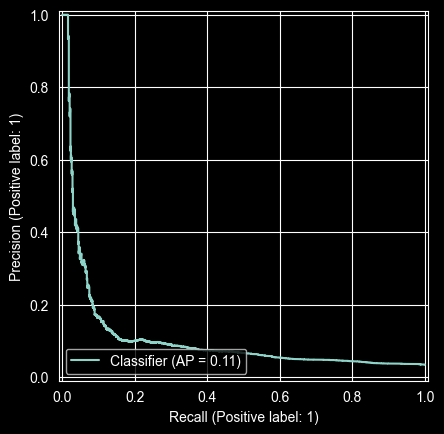

In [4]:
results = evaluate_model(y_test, scores, threshold=cross_val_scores["mean_threshold"], result_path=result_path)
print(results)

In [5]:
import pandas as pd
import os
df = pd.DataFrame(scores, columns=["score"])
scores_path = os.path.join(result_path, "scores.csv")
df.to_csv(scores_path, index=False)